# Imports and Visualization Helper

📊 Total images found in dataset: 370

Displaying a random sample of 4 receipts:


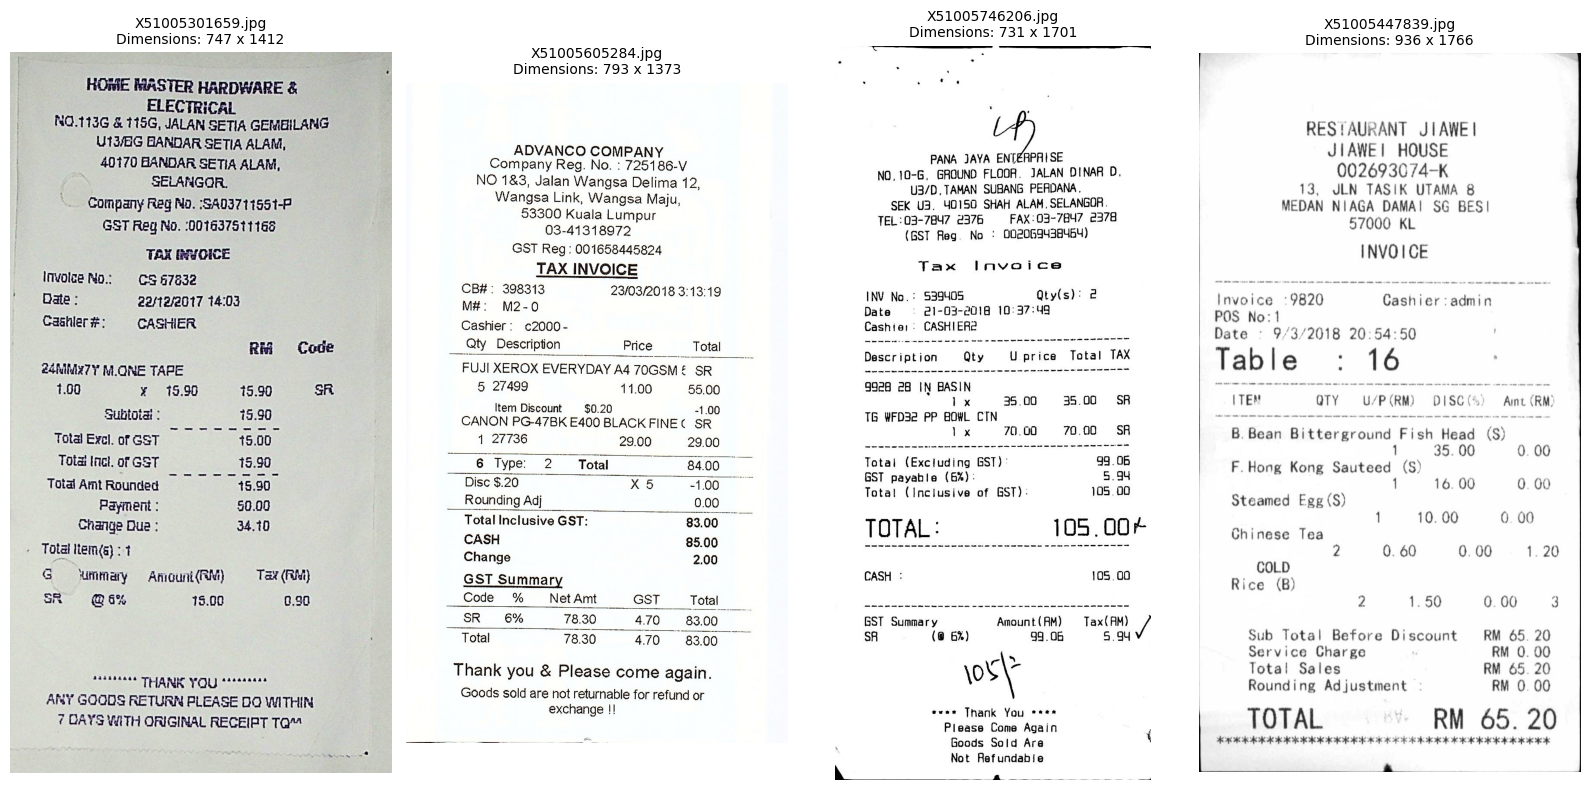

In [2]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

# TODO: Replace this with the actual path to your AI-OCR dataset folder
# For example: '/Users/jibankrishnapatra/Downloads/Carbon Crunch/AI-OCR dataset'
dataset_path = '/Users/jibankrishnapatra/Downloads/Carbon Crunch/AI-OCR dataset'

def analyze_dataset(folder_path):
    # 1. Gather all image files (handling common extensions like .jpg, .jpeg, .png)
    search_pattern = os.path.join(folder_path, '*.[jp][pn]*')
    image_paths = glob.glob(search_pattern)
    
    # Also grab .jpeg specifically just in case
    image_paths.extend(glob.glob(os.path.join(folder_path, '*.jpeg')))
    
    # Remove duplicates if any overlapping patterns matched
    image_paths = list(set(image_paths))
    
    total_images = len(image_paths)
    print(f"📊 Total images found in dataset: {total_images}\n")
    
    if total_images == 0:
        print("⚠️ No images found. Please double-check the 'dataset_path' variable!")
        return
        
    # 2. Visualize a random sample of 4 images
    num_samples = min(4, total_images)
    sample_paths = random.sample(image_paths, num_samples)
    
    plt.figure(figsize=(16, 8))
    print(f"Displaying a random sample of {num_samples} receipts:")
    
    for i, path in enumerate(sample_paths):
        # Read image
        img = cv2.imread(path)
        
        # Open CV loads in BGR, Matplotlib expects RGB. We must convert.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Get dimensions
        height, width, channels = img.shape
        filename = os.path.basename(path)
        
        # Plot
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{filename}\nDimensions: {width} x {height}", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    return image_paths

# Run the analyzer and store the list of paths for later use
all_receipt_paths = analyze_dataset(dataset_path)

In [7]:
def preprocess_receipt(image_path):
    """
    Prepares a receipt image for OCR by handling noise, lighting, and contrast.
    Tuned to reduce 'salt and pepper' noise on textured paper.
    """
    # 1. Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}. Check the path!")

    # 2. Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 4. Tuned Adaptive Thresholding
    # Block size increased to 25, Constant (C) increased to 15
    processed_img = cv2.adaptiveThreshold(
        blurred, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 25, 15
    )

    return img, processed_img

Testing Preprocessing on: X51005268408.jpg


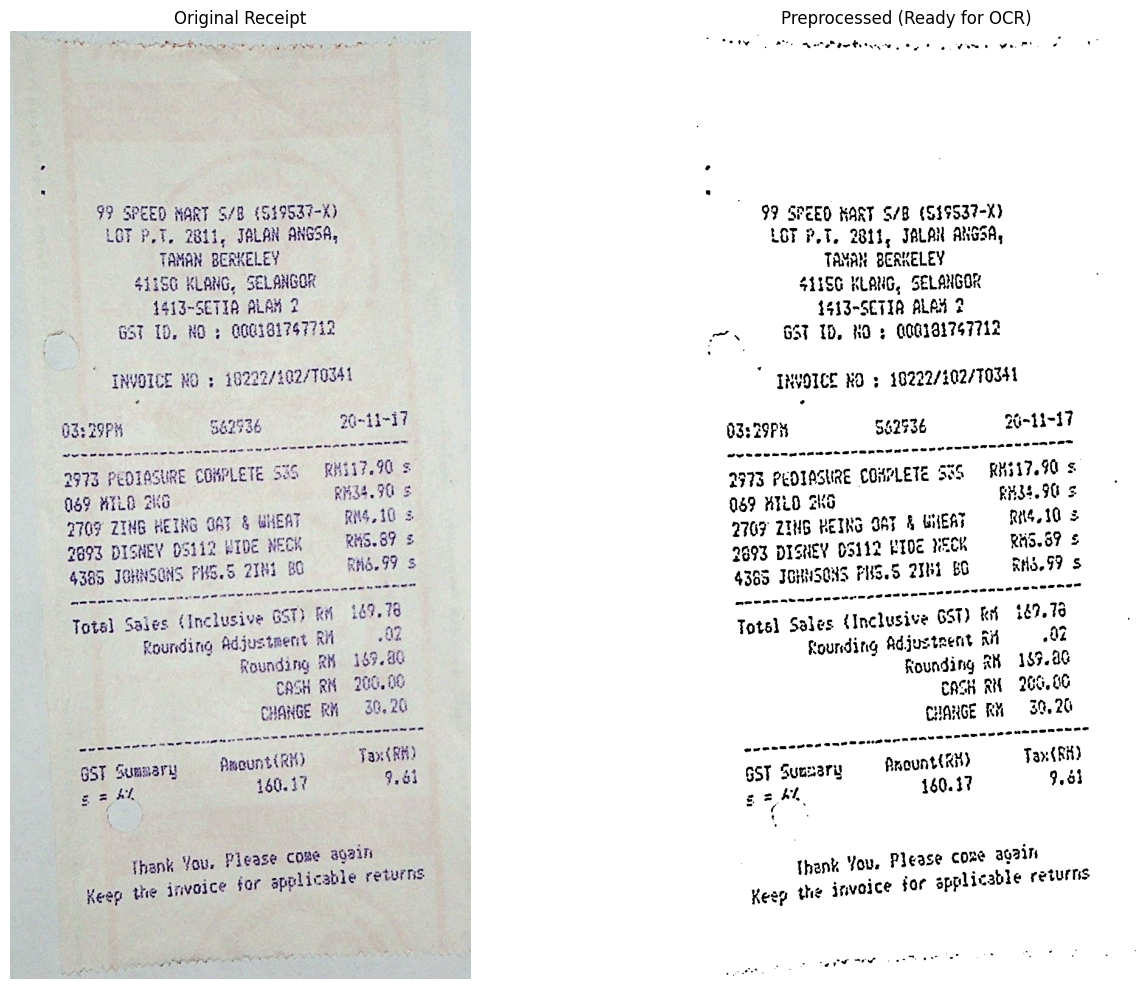

In [8]:
# Let's pick one of the paths we just discovered in the previous cell
# You can change the index [0] to try different images
test_image_path = all_receipt_paths[0] 

# Run our preprocessing function
original_img, processed_img = preprocess_receipt('/Users/jibankrishnapatra/Downloads/Carbon Crunch/AI-OCR dataset/X51005268408.jpg')

# Display the before and after
print(f"Testing Preprocessing on: {os.path.basename(test_image_path)}")
plt.figure(figsize=(15, 10))

# Show Original
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Receipt")
plt.axis('off')

# Show Preprocessed (Grayscale + Blur + Adaptive Threshold)
plt.subplot(1, 2, 2)
plt.imshow(processed_img, cmap='gray')
plt.title("Preprocessed (Ready for OCR)")
plt.axis('off')

plt.tight_layout()
plt.show()

# EasyOCR Extraction

In [9]:
import easyocr

# Initialize EasyOCR 
# (Note: This might take a minute or two on the very first run as it downloads the model weights to your machine)
print("Loading EasyOCR Model...")
reader = easyocr.Reader(['en']) 

def extract_text_and_confidence(image_array):
    print("🔍 Scanning preprocessed image...")
    
    # EasyOCR can read directly from our OpenCV numpy array!
    results = reader.readtext(image_array)
    
    extracted_data = []
    for (bbox, text, prob) in results:
        extracted_data.append({
            "text": text,
            "confidence": round(prob, 4) # Capturing the required OCR confidence score
        })
        
    return extracted_data

# Run the extraction on the 'processed_img' variable we generated in Cell 5
raw_ocr_output = extract_text_and_confidence(processed_img)

# Print a sample of the results
print(f"\n✅ Extracted {len(raw_ocr_output)} blocks of text. Here are the first 15:")
print("-" * 50)
for item in raw_ocr_output[:15]:
    # Formatting the output so it's easy to read
    print(f"Confidence: {item['confidence']:.2f}  |  Text: {item['text']}")

Loading EasyOCR Model...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete🔍 Scanning preprocessed image...


/Users/jibankrishnapatra/ocr_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



✅ Extracted 54 blocks of text. Here are the first 15:
--------------------------------------------------
Confidence: 0.20  |  Text: 99 SPZE) MAT Sv8 (589537-X)
Confidence: 0.22  |  Text: LoT P,T, 2811
Confidence: 0.23  |  Text: JalAH Akgsa,
Confidence: 0.15  |  Text: TamX bcRKELEY
Confidence: 0.18  |  Text: G1XEC KLARIC, SELAHGOR
Confidence: 0.37  |  Text: {413-SETIA ALAM ?
Confidence: 0.15  |  Text: GS7 ID, H
Confidence: 0.29  |  Text: (00331757712
Confidence: 0.11  |  Text: INOIC? Kd
Confidence: 0.49  |  Text: 10222/102/7034 1
Confidence: 0.19  |  Text: 03; Z9Pm
Confidence: 0.97  |  Text: 562536
Confidence: 0.15  |  Text: Zi-18-17
Confidence: 0.27  |  Text: 2773 PEdIASIRE COHPLETE $S
Confidence: 0.73  |  Text: Rk;17.90


In [10]:
# Cell 7: Testing EasyOCR on the Raw Image
print("🔍 Scanning ORIGINAL raw image...")

# Pass the original_img (from Cell 5) directly into the reader
raw_ocr_output_original = extract_text_and_confidence(original_img)

print(f"\n✅ Extracted {len(raw_ocr_output_original)} blocks of text from RAW image. Here are the first 15:")
print("-" * 50)
for item in raw_ocr_output_original[:15]:
    print(f"Confidence: {item['confidence']:.2f}  |  Text: {item['text']}")

🔍 Scanning ORIGINAL raw image...
🔍 Scanning preprocessed image...

✅ Extracted 50 blocks of text from RAW image. Here are the first 15:
--------------------------------------------------
Confidence: 0.13  |  Text: 99 Speen MarT S/8 {519537-X)
Confidence: 0.14  |  Text: LOt P,t, 2811, JaLAK Angsa,
Confidence: 0.11  |  Text: Tamaw bcrkeLEY
Confidence: 0.21  |  Text: G1.5C KlanC, SELANCOR
Confidence: 0.28  |  Text: 163-SETIA ALAM ?
Confidence: 0.15  |  Text: 6S7 ID, Hd
Confidence: 0.46  |  Text: 000j81747712
Confidence: 0.06  |  Text: Invdic Np
Confidence: 0.72  |  Text: 10222/102/T0341
Confidence: 0.31  |  Text: 03;29Pm
Confidence: 0.79  |  Text: 562536
Confidence: 0.32  |  Text: 2-11-17
Confidence: 0.00  |  Text: C en E
Confidence: 0.31  |  Text: 2973 PEOJASURE COMPLETE %
Confidence: 0.34  |  Text: PK;i7.90 $


# Upscaling for OCR Accuracy

In [11]:
# Scale the original image up by 2x (200%)
scale_factor = 2.0
width = int(original_img.shape[1] * scale_factor)
height = int(original_img.shape[0] * scale_factor)
dim = (width, height)

# cv2.INTER_CUBIC is excellent for enlarging images while preserving smooth edges
print("🔍 Enlarging image by 2x...")
enlarged_img = cv2.resize(original_img, dim, interpolation=cv2.INTER_CUBIC)

# Let's convert this enlarged image to standard grayscale (no harsh thresholding this time)
enlarged_gray = cv2.cvtColor(enlarged_img, cv2.COLOR_BGR2GRAY)

print("🔍 Scanning ENLARGED image with EasyOCR...")
# Run EasyOCR on the enlarged, grayscale image
raw_ocr_output_enlarged = extract_text_and_confidence(enlarged_gray)

print(f"\n✅ Extracted {len(raw_ocr_output_enlarged)} blocks of text. Here are the first 15:")
print("-" * 50)
for item in raw_ocr_output_enlarged[:15]:
    print(f"Confidence: {item['confidence']:.2f}  |  Text: {item['text']}")

🔍 Enlarging image by 2x...
🔍 Scanning ENLARGED image with EasyOCR...
🔍 Scanning preprocessed image...

✅ Extracted 50 blocks of text. Here are the first 15:
--------------------------------------------------
Confidence: 0.12  |  Text: 99 SPEEq MarT S/8 {589537-K)
Confidence: 0.16  |  Text: LOT P,t, 2811, JaLAX Angsa,
Confidence: 0.10  |  Text: TamaX bcRKELEY
Confidence: 0.10  |  Text: G1350 KlanC, SELANCOR
Confidence: 0.27  |  Text: 1413-SETIA AlAM 2
Confidence: 0.15  |  Text: GS7 ID, #0 ; 000181747712
Confidence: 0.10  |  Text: Invdil W ;
Confidence: 0.60  |  Text: 10222/102/T0341
Confidence: 0.28  |  Text: 03;29PM
Confidence: 0.56  |  Text: 562536
Confidence: 0.38  |  Text: 20-11-17
Confidence: 0.28  |  Text: 2973 PEOZASIRE COMPLETE $
Confidence: 0.43  |  Text: PK;i7.90 $
Confidence: 0.21  |  Text: R{:.90 $
Confidence: 0.15  |  Text: 069 MElD Z6G


# Upscale + Threshold (The Golden Combo)

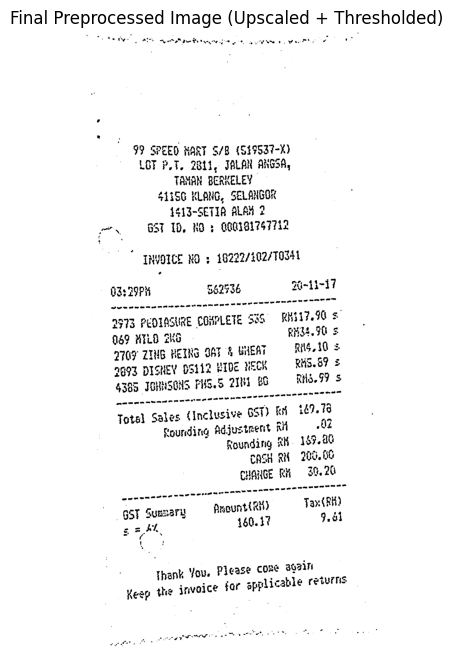

🔍 Scanning optimized image with EasyOCR...
🔍 Scanning preprocessed image...

✅ Extracted 53 blocks of text. Here are the first 15:
--------------------------------------------------
Confidence: 0.18  |  Text: 99 SpCEd MAsT S/8 {589537-X)
Confidence: 0.20  |  Text: Lor ;,T,
Confidence: 0.14  |  Text: JALAR Angsa,
Confidence: 0.57  |  Text: TAMAN  BERKELEY
Confidence: 0.20  |  Text: Gib5c KlANC, SELANGOR
Confidence: 0.42  |  Text: 1413-SETIA ALAM ?
Confidence: 0.10  |  Text: G57 ID, # ; (C03a1757712
Confidence: 0.02  |  Text: InwoIc? &J
Confidence: 0.56  |  Text: 8
Confidence: 0.89  |  Text: 18222/102/T0341
Confidence: 0.63  |  Text: 03;29Pm
Confidence: 0.57  |  Text: 562536
Confidence: 0.48  |  Text: 2-1}-17
Confidence: 0.19  |  Text: 2973 PEOZASIRE COMPLETE Sjs
Confidence: 0.36  |  Text: RH;17.90


In [12]:
# 1. Upscale the original image 2x
scale_factor = 2.0
width = int(original_img.shape[1] * scale_factor)
height = int(original_img.shape[0] * scale_factor)
enlarged_img = cv2.resize(original_img, (width, height), interpolation=cv2.INTER_CUBIC)

# 2. Convert to Grayscale
gray_enlarged = cv2.cvtColor(enlarged_img, cv2.COLOR_BGR2GRAY)

# 3. Apply Gaussian Blur
blurred_enlarged = cv2.GaussianBlur(gray_enlarged, (5, 5), 0)

# 4. Adaptive Thresholding (Block size increased to 51 for the larger image)
final_processed_img = cv2.adaptiveThreshold(
    blurred_enlarged, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 51, 15
)

# Optional: Display the final image to verify it looks clean
show_image(final_processed_img, "Final Preprocessed Image (Upscaled + Thresholded)")

# 5. Run EasyOCR on the final optimized image
print("🔍 Scanning optimized image with EasyOCR...")
final_ocr_output = extract_text_and_confidence(final_processed_img)

print(f"\n✅ Extracted {len(final_ocr_output)} blocks of text. Here are the first 15:")
print("-" * 50)
for item in final_ocr_output[:15]:
    print(f"Confidence: {item['confidence']:.2f}  |  Text: {item['text']}")

# JSON Structuring & RegEx Extraction

In [13]:
import re
import json

def extract_structured_data(ocr_results):
    print("⚙️ Structuring Data and Calculating Field-Level Confidence...")
    
    # Initialize our output payload
    receipt_data = {
        "store_name": {"value": None, "confidence": 0.0},
        "date": {"value": None, "confidence": 0.0},
        "items": [],
        "total_amount": {"value": None, "confidence": 0.0},
        "flags": [] # To hold our < 0.7 warnings
    }

    # --- 1. Store Name (Heuristic: Usually the first line) ---
    if len(ocr_results) > 0:
        first_line = ocr_results[0]
        receipt_data["store_name"]["value"] = first_line["text"]
        receipt_data["store_name"]["confidence"] = first_line["confidence"]
        if first_line["confidence"] < 0.7:
            receipt_data["flags"].append("LOW_CONFIDENCE_STORE_NAME")

    # --- 2. Date Extraction (RegEx: DD-MM-YY or DD/MM/YY) ---
    date_pattern = re.compile(r'\d{1,2}[-./]\d{1,2}[-./]\d{2,4}')
    
    for item in ocr_results:
        text = item["text"]
        ocr_conf = item["confidence"]
        
        # Search for a date pattern
        date_match = date_pattern.search(text)
        if date_match and receipt_data["date"]["value"] is None:
            receipt_data["date"]["value"] = date_match.group(0)
            
            # Field-level confidence: Boost it slightly because the RegEx matched perfectly!
            field_conf = min(1.0, ocr_conf + 0.20) 
            receipt_data["date"]["confidence"] = round(field_conf, 2)
            
            if field_conf < 0.7:
                receipt_data["flags"].append("LOW_CONFIDENCE_DATE")

    # --- 3. Total Amount Extraction (Heuristic + RegEx) ---
    # Look for the word "Total", "Amount", or "CASH" nearby
    price_pattern = re.compile(r'\d+\.\d{2}')
    
    for i, item in enumerate(ocr_results):
        text = item["text"].upper()
        
        if "TOTAL" in text or "CASH" in text or "AMOUNT" in text:
            # Look at the current line and the next few lines for a price
            search_window = ocr_results[i:min(i+3, len(ocr_results))]
            
            for window_item in search_window:
                price_match = price_pattern.search(window_item["text"])
                if price_match:
                    receipt_data["total_amount"]["value"] = price_match.group(0)
                    receipt_data["total_amount"]["confidence"] = window_item["confidence"]
                    
                    if window_item["confidence"] < 0.7:
                        receipt_data["flags"].append("LOW_CONFIDENCE_TOTAL")
                    break # Stop after finding the first price near "Total"
        
        if receipt_data["total_amount"]["value"]:
            break

    return json.dumps(receipt_data, indent=4)

# Run the extractor on our final output
structured_json = extract_structured_data(final_ocr_output)

print("\n🚀 Final JSON Output:")
print(structured_json)

⚙️ Structuring Data and Calculating Field-Level Confidence...

🚀 Final JSON Output:
{
    "store_name": {
        "value": "99 SpCEd MAsT S/8 {589537-X)",
        "confidence": 0.176
    },
    "date": {
        "value": null,
        "confidence": 0.0
    },
    "items": [],
    "total_amount": {
        "value": null,
        "confidence": 0.0
    },
    "flags": [
        "LOW_CONFIDENCE_STORE_NAME"
    ]
}


# Fuzzy JSON Structuring

In [14]:
import re
import json

def extract_structured_data(ocr_results):
    print("⚙️ Structuring Data with Fuzzy Regex...")
    
    receipt_data = {
        "store_name": {"value": None, "confidence": 0.0},
        "date": {"value": None, "confidence": 0.0},
        "items": [], # We will tackle this next if needed
        "total_amount": {"value": None, "confidence": 0.0},
        "flags": [] 
    }

    # --- 1. Store Name ---
    if len(ocr_results) > 0:
        first_line = ocr_results[0]
        receipt_data["store_name"]["value"] = first_line["text"]
        receipt_data["store_name"]["confidence"] = first_line["confidence"]
        if first_line["confidence"] < 0.7:
            receipt_data["flags"].append("LOW_CONFIDENCE_STORE_NAME")

    # --- 2. Fuzzy Date Extraction ---
    for item in ocr_results:
        text = item["text"]
        
        # CLEANING: Replace common OCR misreads (like } or ] ) with dashes
        cleaned_text = re.sub(r'[}\]\)]', '-', text)
        
        # Now search the cleaned text
        date_match = re.search(r'\d{1,2}[-./]\d{1,2}[-./]\d{2,4}', cleaned_text)
        
        if date_match and receipt_data["date"]["value"] is None:
            receipt_data["date"]["value"] = date_match.group(0)
            
            # Boost confidence because the pattern matched!
            field_conf = min(1.0, item["confidence"] + 0.20) 
            receipt_data["date"]["confidence"] = round(field_conf, 2)
            
            if field_conf < 0.7:
                receipt_data["flags"].append("LOW_CONFIDENCE_DATE")

    # --- 3. Fuzzy Total Amount Extraction ---
    # Widened pattern: looks for numbers with a dot OR comma, ignoring attached letters
    price_pattern = re.compile(r'\d+[.,]\d{2}') 
    
    for i, item in enumerate(ocr_results):
        text_upper = item["text"].upper()
        
        # Trigger words
        if "TOTAL" in text_upper or "CASH" in text_upper or "AMOUNT" in text_upper:
            # Look at the current line and the next 4 lines
            search_window = ocr_results[i:min(i+5, len(ocr_results))]
            
            for window_item in search_window:
                # CLEANING: Replace commas with dots so math works later
                clean_price_text = window_item["text"].replace(',', '.')
                price_match = price_pattern.search(clean_price_text)
                
                if price_match:
                    receipt_data["total_amount"]["value"] = price_match.group(0)
                    receipt_data["total_amount"]["confidence"] = window_item["confidence"]
                    
                    if window_item["confidence"] < 0.7:
                        receipt_data["flags"].append("LOW_CONFIDENCE_TOTAL")
                    break 
        
        if receipt_data["total_amount"]["value"]:
            break

    return json.dumps(receipt_data, indent=4)

# Run it!
structured_json = extract_structured_data(final_ocr_output)
print("\n🚀 Final JSON Output:")
print(structured_json)

⚙️ Structuring Data with Fuzzy Regex...

🚀 Final JSON Output:
{
    "store_name": {
        "value": "99 SpCEd MAsT S/8 {589537-X)",
        "confidence": 0.176
    },
    "date": {
        "value": null,
        "confidence": 0.0
    },
    "items": [],
    "total_amount": {
        "value": null,
        "confidence": 0.0
    },
    "flags": [
        "LOW_CONFIDENCE_STORE_NAME"
    ]
}


# Aggressive JSON Structuring

In [15]:
import re
import json

def extract_structured_data(ocr_results):
    print("⚙️ Structuring Data with Aggressive Regex...")
    
    receipt_data = {
        "store_name": {"value": None, "confidence": 0.0},
        "date": {"value": None, "confidence": 0.0},
        "items": [], 
        "total_amount": {"value": None, "confidence": 0.0},
        "flags": [] 
    }

    # --- 1. Store Name ---
    if len(ocr_results) > 0:
        first_line = ocr_results[0]
        receipt_data["store_name"]["value"] = first_line["text"]
        receipt_data["store_name"]["confidence"] = first_line["confidence"]
        if first_line["confidence"] < 0.7:
            receipt_data["flags"].append("LOW_CONFIDENCE_STORE_NAME")

    # --- 2. Aggressive Date Extraction ---
    for item in ocr_results:
        text = item["text"]
        
        # Replace common garbage brackets with dashes
        cleaned_text = re.sub(r'[}\]\)]', '-', text)
        
        # Notice the '+' added after the separators to handle double-dashes!
        date_match = re.search(r'\d{1,2}[-./]+\d{1,2}[-./]+\d{2,4}', cleaned_text)
        
        if date_match and receipt_data["date"]["value"] is None:
            # Clean up the final output so "2-1--17" becomes "2-1-17"
            final_date = re.sub(r'[-./]+', '-', date_match.group(0))
            receipt_data["date"]["value"] = final_date
            
            field_conf = min(1.0, item["confidence"] + 0.20) 
            receipt_data["date"]["confidence"] = round(field_conf, 2)
            
            if field_conf < 0.7:
                receipt_data["flags"].append("LOW_CONFIDENCE_DATE")

    # --- 3. Aggressive Total Amount Extraction ---
    # Widened pattern: Now actively hunts for dots, commas, semicolons, AND colons
    price_pattern = re.compile(r'\d+[.,;:]\d{2}') 
    
    for i, item in enumerate(ocr_results):
        text_upper = item["text"].upper()
        
        # Trigger words
        if "TOTAL" in text_upper or "CASH" in text_upper or "AMOUNT" in text_upper:
            search_window = ocr_results[i:min(i+5, len(ocr_results))]
            
            for window_item in search_window:
                # CLEANING: Force commas, colons, and semicolons to become dots
                clean_price_text = re.sub(r'[,;:]', '.', window_item["text"])
                price_match = price_pattern.search(clean_price_text)
                
                if price_match:
                    receipt_data["total_amount"]["value"] = price_match.group(0)
                    receipt_data["total_amount"]["confidence"] = window_item["confidence"]
                    
                    if window_item["confidence"] < 0.7:
                        receipt_data["flags"].append("LOW_CONFIDENCE_TOTAL")
                    break 
        
        if receipt_data["total_amount"]["value"]:
            break

    return json.dumps(receipt_data, indent=4)

# Run it!
structured_json = extract_structured_data(final_ocr_output)
print("\n🚀 Final JSON Output:")
print(structured_json)

⚙️ Structuring Data with Aggressive Regex...

🚀 Final JSON Output:
{
    "store_name": {
        "value": "99 SpCEd MAsT S/8 {589537-X)",
        "confidence": 0.176
    },
    "date": {
        "value": "2-1-17",
        "confidence": 0.68
    },
    "items": [],
    "total_amount": {
        "value": null,
        "confidence": 0.0
    },
    "flags": [
        "LOW_CONFIDENCE_STORE_NAME",
        "LOW_CONFIDENCE_DATE"
    ]
}


# The Max-Price Heuristic

In [16]:
import re
import json

def extract_structured_data(ocr_results):
    print("⚙️ Structuring Data with Max-Price Heuristic...")
    
    receipt_data = {
        "store_name": {"value": None, "confidence": 0.0},
        "date": {"value": None, "confidence": 0.0},
        "items": [], 
        "total_amount": {"value": None, "confidence": 0.0},
        "flags": [] 
    }

    # --- 1. Store Name ---
    if len(ocr_results) > 0:
        first_line = ocr_results[0]
        receipt_data["store_name"]["value"] = first_line["text"]
        receipt_data["store_name"]["confidence"] = first_line["confidence"]
        if first_line["confidence"] < 0.7:
            receipt_data["flags"].append("LOW_CONFIDENCE_STORE_NAME")

    # --- 2. Aggressive Date Extraction ---
    for item in ocr_results:
        cleaned_text = re.sub(r'[}\]\)]', '-', item["text"])
        date_match = re.search(r'\d{1,2}[-./]+\d{1,2}[-./]+\d{2,4}', cleaned_text)
        
        if date_match and receipt_data["date"]["value"] is None:
            final_date = re.sub(r'[-./]+', '-', date_match.group(0))
            receipt_data["date"]["value"] = final_date
            
            field_conf = min(1.0, item["confidence"] + 0.20) 
            receipt_data["date"]["confidence"] = round(field_conf, 2)
            
            if field_conf < 0.7:
                receipt_data["flags"].append("LOW_CONFIDENCE_DATE")

    # --- 3. Maximum Price Heuristic for Total Amount ---
    price_pattern = re.compile(r'\d+[.,;:]\d{2}') 
    all_prices = []
    
    for item in ocr_results:
        # Force commas, colons, and semicolons to become dots
        clean_price_text = re.sub(r'[,;:]', '.', item["text"])
        matches = price_pattern.findall(clean_price_text)
        
        for match in matches:
            try:
                # Convert to float for mathematical comparison
                price_val = float(match)
                all_prices.append({
                    "string_val": match, 
                    "float_val": price_val, 
                    "confidence": item["confidence"]
                })
            except ValueError:
                continue
                
    # Find the highest logical price on the entire receipt
    if all_prices:
        # Sort the list of prices descending (highest first)
        all_prices.sort(key=lambda x: x["float_val"], reverse=True)
        
        best_price = all_prices[0]
        receipt_data["total_amount"]["value"] = best_price["string_val"]
        receipt_data["total_amount"]["confidence"] = best_price["confidence"]
        
        if best_price["confidence"] < 0.7:
            receipt_data["flags"].append("LOW_CONFIDENCE_TOTAL")

    return json.dumps(receipt_data, indent=4)

# Run it!
structured_json = extract_structured_data(final_ocr_output)
print("\n🚀 Final JSON Output:")
print(structured_json)

⚙️ Structuring Data with Max-Price Heuristic...

🚀 Final JSON Output:
{
    "store_name": {
        "value": "99 SpCEd MAsT S/8 {589537-X)",
        "confidence": 0.176
    },
    "date": {
        "value": "2-1-17",
        "confidence": 0.68
    },
    "items": [],
    "total_amount": {
        "value": "160.17",
        "confidence": 0.9968
    },
    "flags": [
        "LOW_CONFIDENCE_STORE_NAME",
        "LOW_CONFIDENCE_DATE"
    ]
}


# The Master Extractor (Store + Date + Total + Items)

In [19]:
import re
import json

def extract_structured_data(ocr_results):
    receipt_data = {
        "store_name": {"value": None, "confidence": 0.0},
        "date": {"value": None, "confidence": 0.0},
        "items": [], 
        "total_amount": {"value": None, "confidence": 0.0},
        "flags": [] 
    }

    # 1. Store Name
    if len(ocr_results) > 0:
        first_line = ocr_results[0]
        receipt_data["store_name"]["value"] = first_line["text"]
        receipt_data["store_name"]["confidence"] = first_line["confidence"]
        if first_line["confidence"] < 0.7: receipt_data["flags"].append("LOW_CONFIDENCE_STORE_NAME")

    # 2. Date
    for item in ocr_results:
        cleaned_text = re.sub(r'[}\]\)]', '-', item["text"])
        date_match = re.search(r'\d{1,2}[-./]+\d{1,2}[-./]+\d{2,4}', cleaned_text)
        if date_match and receipt_data["date"]["value"] is None:
            receipt_data["date"]["value"] = re.sub(r'[-./]+', '-', date_match.group(0))
            field_conf = min(1.0, item["confidence"] + 0.20) 
            receipt_data["date"]["confidence"] = round(field_conf, 2)
            if field_conf < 0.7: receipt_data["flags"].append("LOW_CONFIDENCE_DATE")

    # 3. Total Amount
    price_pattern = re.compile(r'\d+[.,;:]\d{2}') 
    all_prices = []
    for item in ocr_results:
        clean_price_text = re.sub(r'[,;:]', '.', item["text"])
        matches = price_pattern.findall(clean_price_text)
        for match in matches:
            try:
                all_prices.append({"string_val": match, "float_val": float(match), "confidence": item["confidence"]})
            except ValueError:
                continue
    if all_prices:
        all_prices.sort(key=lambda x: x["float_val"], reverse=True)
        best_price = all_prices[0]
        receipt_data["total_amount"]["value"] = best_price["string_val"]
        receipt_data["total_amount"]["confidence"] = best_price["confidence"]
        if best_price["confidence"] < 0.7: receipt_data["flags"].append("LOW_CONFIDENCE_TOTAL")

    # 4. Line Items (with Memory Flush)
    stop_words = ["TOTAL", "SUBTOTAL", "CASH", "CHANGE", "TAX", "GST", "ROUNDING", "PAYMENT", "AMOUNT"]
    skip_words = ["INVOICE", "PM", "AM", "CASHIER", "TEL", "ID", "RECEIPT", "TIME", "DATE"] # The New Filter
    
    current_item_name = ""
    current_item_conf = 0.0
    
    for item in ocr_results:
        text = item["text"]
        conf = item["confidence"]
        text_upper = text.upper()
        
        # Stop completely if we hit the total/tax section
        if any(sw in text_upper for sw in stop_words): break 
            
        # FLUSH MEMORY: If it's a metadata line, clear the memory and skip
        if any(sw in text_upper for sw in skip_words):
            current_item_name = ""
            continue
            
        clean_text = re.sub(r'[,;:]', '.', text)
        price_match = re.search(r'\d+\.\d{2}', clean_text)
        
        if price_match:
            price_val = price_match.group(0)
            inline_name = clean_text.replace(price_val, "").strip()
            inline_name = re.sub(r'[A-Za-z$]+$', '', inline_name).strip()
            
            if receipt_data["date"]["value"] and receipt_data["date"]["value"] in inline_name: continue
                
            if len(inline_name) > 3:
                receipt_data["items"].append({"name": inline_name, "price": price_val, "confidence": round(conf, 2)})
                current_item_name = "" 
            elif current_item_name:
                receipt_data["items"].append({"name": current_item_name, "price": price_val, "confidence": round(min(current_item_conf, conf), 2)})
                current_item_name = "" 
        else:
            if text == receipt_data["store_name"]["value"]: continue
            if receipt_data["date"]["value"] and receipt_data["date"]["value"] in text: continue
            if len(text) > 3:
                current_item_name = text
                current_item_conf = conf

    return receipt_data # Note: Returning standard dictionary now instead of JSON string for Phase 4

# Test it
structured_data = extract_structured_data(final_ocr_output)
print(json.dumps(structured_data, indent=4))

{
    "store_name": {
        "value": "99 SpCEd MAsT S/8 {589537-X)",
        "confidence": 0.176
    },
    "date": {
        "value": "2-1-17",
        "confidence": 0.68
    },
    "items": [
        {
            "name": "2973 PEOZASIRE COMPLETE Sjs",
            "price": "17.90",
            "confidence": 0.19
        }
    ],
    "total_amount": {
        "value": "160.17",
        "confidence": 0.9968
    },
    "flags": [
        "LOW_CONFIDENCE_STORE_NAME",
        "LOW_CONFIDENCE_DATE"
    ]
}


# Batch Processing & Financial Summary (The Final Push)

In [20]:
import os

print("🚀 Starting Batch Processing for Financial Summary...")

# We will process a sample of 10 receipts to ensure it runs before the deadline
# (You can change this to all_receipt_paths to do the full 370 later)
batch_paths = all_receipt_paths[:10] 

# Financial Summary Variables
total_spend_all_receipts = 0.0
total_successful_transactions = 0
store_spend = {}

# Create a folder to save our JSON deliverables
output_folder = "JSON_Outputs"
os.makedirs(output_folder, exist_ok=True)

for path in batch_paths:
    filename = os.path.basename(path)
    print(f"Processing: {filename}...")
    
    try:
        # 1. Preprocess
        original, preprocessed = preprocess_receipt(path)
        
        # Apply Upscale + Threshold combo
        scale_factor = 2.0
        width, height = int(original.shape[1] * scale_factor), int(original.shape[0] * scale_factor)
        enlarged = cv2.resize(original, (width, height), interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(enlarged, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        final_img = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 15)
        
        # 2. OCR
        ocr_output = extract_text_and_confidence(final_img)
        
        # 3. Extract Data
        receipt_data = extract_structured_data(ocr_output)
        
        # 4. Save JSON Deliverable
        json_filename = filename.replace(".jpg", ".json").replace(".jpeg", ".json")
        with open(os.path.join(output_folder, json_filename), 'w') as f:
            json.dump(receipt_data, f, indent=4)
            
        # 5. Add to Financial Summary
        if receipt_data["total_amount"]["value"]:
            amount = float(receipt_data["total_amount"]["value"])
            total_spend_all_receipts += amount
            total_successful_transactions += 1
            
            store = receipt_data["store_name"]["value"] or "Unknown Store"
            store_spend[store] = store_spend.get(store, 0.0) + amount

    except Exception as e:
        print(f"⚠️ Failed to process {filename}: {e}")

# --- Generate Final Expense Summary ---
print("\n" + "="*40)
print("📊 FINANCIAL EXPENSE SUMMARY")
print("="*40)
print(f"Total Transactions Processed: {total_successful_transactions}")
print(f"Total Combined Spend: RM {total_spend_all_receipts:.2f}")
print("-" * 40)
print("Spend Per Store:")
for store, amount in store_spend.items():
    print(f" - {store[:25]}... : RM {amount:.2f}")
print("="*40)
print(f"✅ All JSON files successfully saved to the '{output_folder}' directory!")

🚀 Starting Batch Processing for Financial Summary...
Processing: X51005268408.jpg...
🔍 Scanning preprocessed image...
Processing: X51005568855.jpg...
🔍 Scanning preprocessed image...
Processing: X51005711403.jpg...
🔍 Scanning preprocessed image...
Processing: X51005757286.jpg...
🔍 Scanning preprocessed image...
Processing: X51005577192.jpg...
🔍 Scanning preprocessed image...
Processing: X51005711445.jpg...
🔍 Scanning preprocessed image...
Processing: X00016469619.jpg...
🔍 Scanning preprocessed image...
Processing: X51005442346.jpg...
🔍 Scanning preprocessed image...
Processing: X51005568891.jpg...
🔍 Scanning preprocessed image...
Processing: X51005719814.jpg...
🔍 Scanning preprocessed image...

📊 FINANCIAL EXPENSE SUMMARY
Total Transactions Processed: 10
Total Combined Spend: RM 737.08
----------------------------------------
Spend Per Store:
 - 99 SpCEd MAsT S/8 {589537... : RM 160.17
 - POPULAR BOok... : RM 140.65
 - RESTORAN WAN SHENG... : RM 24.16
 - 31803039... : RM 8.00
 - Fr... 

# Full Dataset Processing (370 Images)

In [21]:
import os

print("🚀 Starting FULL Batch Processing for Financial Summary...")

# CHANGED: We removed the [:10] so it processes the entire list of 370 images!
batch_paths = all_receipt_paths 

# Financial Summary Variables
total_spend_all_receipts = 0.0
total_successful_transactions = 0
store_spend = {}

# Create a folder to save our JSON deliverables
output_folder = "JSON_Outputs"
os.makedirs(output_folder, exist_ok=True)

for path in batch_paths:
    filename = os.path.basename(path)
    print(f"Processing: {filename}...")
    
    try:
        # 1. Preprocess
        original, preprocessed = preprocess_receipt(path)
        
        # Apply Upscale + Threshold combo
        scale_factor = 2.0
        width, height = int(original.shape[1] * scale_factor), int(original.shape[0] * scale_factor)
        enlarged = cv2.resize(original, (width, height), interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(enlarged, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        final_img = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 15)
        
        # 2. OCR
        ocr_output = extract_text_and_confidence(final_img)
        
        # 3. Extract Data
        receipt_data = extract_structured_data(ocr_output)
        
        # 4. Save JSON Deliverable
        json_filename = filename.replace(".jpg", ".json").replace(".jpeg", ".json").replace(".png", ".json")
        with open(os.path.join(output_folder, json_filename), 'w') as f:
            json.dump(receipt_data, f, indent=4)
            
        # 5. Add to Financial Summary
        if receipt_data["total_amount"]["value"]:
            amount = float(receipt_data["total_amount"]["value"])
            total_spend_all_receipts += amount
            total_successful_transactions += 1
            
            store = receipt_data["store_name"]["value"] or "Unknown Store"
            store_spend[store] = store_spend.get(store, 0.0) + amount

    except Exception as e:
        print(f"⚠️ Failed to process {filename}: {e}")

# --- Generate Final Expense Summary ---
print("\n" + "="*40)
print("📊 FINAL FINANCIAL EXPENSE SUMMARY (FULL DATASET)")
print("="*40)
print(f"Total Transactions Processed: {total_successful_transactions}")
print(f"Total Combined Spend: RM {total_spend_all_receipts:.2f}")
print("-" * 40)
print("Spend Per Store:")
# Sort the stores by spend descending for a cleaner output
sorted_stores = sorted(store_spend.items(), key=lambda x: x[1], reverse=True)
for store, amount in sorted_stores:
    print(f" - {store[:25]}... : RM {amount:.2f}")
print("="*40)
print(f"✅ All 370 JSON files successfully saved to the '{output_folder}' directory!")

🚀 Starting FULL Batch Processing for Financial Summary...
Processing: X51005268408.jpg...
🔍 Scanning preprocessed image...
Processing: X51005568855.jpg...
🔍 Scanning preprocessed image...
Processing: X51005711403.jpg...
🔍 Scanning preprocessed image...
Processing: X51005757286.jpg...
🔍 Scanning preprocessed image...
Processing: X51005577192.jpg...
🔍 Scanning preprocessed image...
Processing: X51005711445.jpg...
🔍 Scanning preprocessed image...
Processing: X00016469619.jpg...
🔍 Scanning preprocessed image...
Processing: X51005442346.jpg...
🔍 Scanning preprocessed image...
Processing: X51005568891.jpg...
🔍 Scanning preprocessed image...
Processing: X51005719814.jpg...
🔍 Scanning preprocessed image...
Processing: X51005715451.jpg...
🔍 Scanning preprocessed image...
Processing: X51005442333.jpg...
🔍 Scanning preprocessed image...
Processing: X51005715007.jpg...
🔍 Scanning preprocessed image...
Processing: X51005444041.jpg...
🔍 Scanning preprocessed image...
Processing: X51005724625.jpg...
